In [ ]:
!pip install simpy

In [ ]:
# === RRT* + OBSTACLE ===
import numpy as np

def is_collision(point, obstacles):
    for obs in obstacles:
        center, radius = obs
        if np.linalg.norm(point - center) < radius + 2:
            return True
    return False


def is_path_collision(p1, p2, obstacles):
    dist = np.linalg.norm(p2 - p1)
    steps = int(dist * 5)

    for i in range(steps + 1):
        t = i / steps if steps != 0 else 0
        point = p1 * (1 - t) + p2 * t
        for center, radius in obstacles:
            if np.linalg.norm(point - center) <= radius + 2:
                return True
    return False

    for i in range(steps):
        point = p1 + i * step * direction
        if is_collision(point, obstacles):
            return True

    return False


def distance(a, b):
    return np.linalg.norm(a - b)


def rrt_star(start, goal, obstacles, max_iter=1000, step_size=5, radius=20):
    nodes = [start]
    parent = {tuple(start): None}
    cost = {tuple(start): 0}

    for _ in range(max_iter):
        rand = np.random.uniform(0, 100, 2)
        rand = np.append(rand, 0)

        nearest = min(nodes, key=lambda n: distance(n, rand))
        direction = rand - nearest

        if np.linalg.norm(direction) == 0:
            continue
        direction = direction / np.linalg.norm(direction)

        new_node = nearest + step_size * direction

        if is_collision(new_node, obstacles) or is_path_collision(nearest, new_node, obstacles):
            continue

        new_node_t = tuple(new_node)
        neighbors = [n for n in nodes if distance(n, new_node) < radius]

        best_parent = tuple(nearest)
        min_cost = cost[tuple(nearest)] + distance(nearest, new_node)
        for n in neighbors:
            c = cost[tuple(n)] + distance(n, new_node)
            if c < min_cost:
                best_parent = tuple(n)
                min_cost = c

        nodes.append(new_node)
        parent[new_node_t] = best_parent
        cost[new_node_t] = min_cost

        # REWIRING
        if distance(new_node, goal) < step_size:
          if not is_path_collision(new_node, goal, obstacles):
            nodes.append(goal)
            parent[tuple(goal)] = new_node_t
            cost[tuple(goal)] = cost[new_node_t] + distance(new_node, goal)
            break

    #=== REKONSTRUKSI PATH ===
    if tuple(goal) in parent:
        current = tuple(goal)
    else:
        closest = min(nodes, key=lambda n: np.linalg.norm(n - goal))
        current = tuple(closest)

    path = []
    while current is not None:
        path.append(current)
        current = parent.get(current)

    return path[::-1]

In [ ]:
# === VISUALIZATION ====
import matplotlib.pyplot as plt

def plot_path(path, start, goal, obstacles):
    if len(path) == 0:
        print("Path tidak ditemukan")
        return

    path = np.array(path)

    plt.figure()

    # path
    plt.plot(path[:,0], path[:,1], marker='o', linewidth=2)

    # start & goal
    plt.scatter(start[0], start[1], s=100, label="Start")
    plt.scatter(goal[0], goal[1], s=100, label="Goal")

    # obstacles
    for center, radius in obstacles:
        circle = plt.Circle((center[0], center[1]), radius, alpha=0.3)
        plt.gca().add_patch(circle)

    plt.axis('equal')
    plt.legend()
    plt.title("RRT* Path Planning")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

Path length: 12


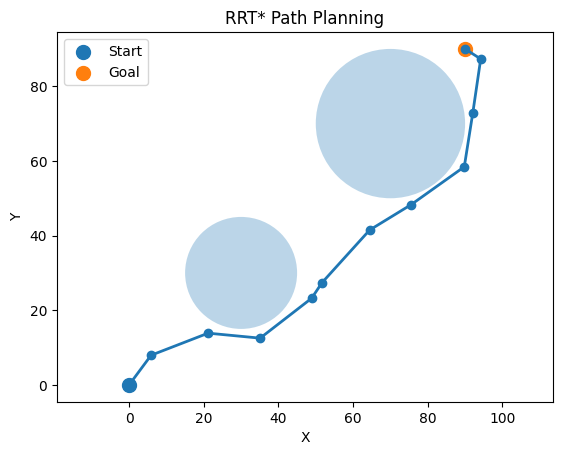

In [ ]:
start = np.array([0, 0, 0])
goal = np.array([90, 90, 0])

obstacles = [
    (np.array([30, 30, 0]), 15),
    (np.array([70, 70, 0]), 20),
]

path = rrt_star(start, goal, obstacles)

print("Path length:", len(path))

plot_path(path, start, goal, obstacles)

In [ ]:
# ==== FALCONIS SYSTEM ====

import numpy as np
import simpy

class Node:
    def __init__(self, name):
        self.name = name

# ==== VICTIM ====
class Victim(Node):
    def __init__(self, env, name, pos, severity):
        super().__init__(name)
        self.env = env
        self.pos = np.array(pos)
        self.severity = severity

# ==== UAV (DETEKSI)====
class UAV(Node):
    def __init__(self, env, name, pos, speed):
        super().__init__(name)
        self.env = env
        self.pos = np.array(pos)
        self.speed = speed

    def detect_victim(self, victim):
        distance = np.linalg.norm(self.pos - victim.pos)
        detection_time = distance / self.speed
        return detection_time

# ==== UGV (RESPON) ====
class UGV(Node):
    def __init__(self, env, name, pos, speed, capacity, obstacles):
        super().__init__(name)
        self.env = env
        self.pos = np.array(pos)
        self.speed = speed
        self.capacity = capacity
        self.obstacles = obstacles

    def move_to_victim(self, victim, path):
      if np.linalg.norm(self.pos - victim.pos) < 1e-3:
        self.pos = victim.pos
        return 0.0
      if len(path) < 2:
        return float('inf')
      distance_total = 0.0
      for i in range(len(path) - 1):
        p1 = np.array(path[i])
        p2 = np.array(path[i + 1])
        distance_total += np.linalg.norm(p1 - p2)
      travel_time = distance_total / self.speed
      self.pos = victim.pos
      return travel_time

def random_free_point(obstacles):
    while True:
        point = np.random.uniform(0, 100, 3)
        collision = False
        for center, radius in obstacles:
            if np.linalg.norm(point - center) < radius + 5:
                collision = True
                break
        if not collision:
            return point

# === SETUP ENVIRONMENT====
def setup_falconis(env, num_victims=10, num_uav=2, num_ugv=2):
    default_obstacles = [
        (np.array([30, 30, 0]), 10),
        (np.array([70, 70, 0]), 15)
    ]

    def rand_pos():
        xy = np.random.uniform(0, 100, 2)
        return np.append(xy, 0)

    victims = [
        Victim(env, f"Victim-{i}", pos=rand_pos(), severity=np.random.randint(1, 5))
        for i in range(num_victims)
    ]

    uavs = [
        UAV(env, f"UAV-{i}", pos=rand_pos(), speed=np.random.uniform(20, 40))
        for i in range(num_uav)
    ]

    ugvs = [
        UGV(env, f"UGV-{i}", pos=rand_pos(), speed=np.random.uniform(5, 15),
            capacity=2, obstacles=default_obstacles)
        for i in range(num_ugv)
    ]

    return victims, uavs, ugvs


# ==== SIMPLE ASSIGNMENT ====
def assign_victims(uavs, ugvs, victims):
    assignments = []

    for victim in victims:
        best_uav = min(uavs, key=lambda u: np.linalg.norm(u.pos - victim.pos))
        best_ugv = min(ugvs, key=lambda g: np.linalg.norm(g.pos - victim.pos))
        assignments.append((victim, best_uav, best_ugv))

    return assignments

# ==== SIMULATION PROCESS ====
def falconis_process(env, victims, uavs, ugvs):
    print(f"\n[{env.now:.2f}s] === FALCONIS START ===")

    assignments = assign_victims(uavs, ugvs, victims)

    for i, (victim, uav, ugv) in enumerate(assignments):
        detect_time = uav.detect_victim(victim)
        yield env.timeout(detect_time)

        path = rrt_star(ugv.pos, victim.pos, ugv.obstacles)

        print(f"DEBUG {victim.name}: len(path) = {len(path)}")
        if i == 0:
            if len(path) <= 1:
                print("Path korban pertama tidak ditemukan / hanya 1 titik, jadi nggak diplot garis.")
            else:
                plot_path(path, ugv.pos, victim.pos, ugv.obstacles)

        travel_time = ugv.move_to_victim(victim, path)

        if np.isinf(travel_time):
            print(f"[{env.now:.2f}s] {victim.name} → {uav.name} (detect: {detect_time:.2f}s) "
                  f"→ {ugv.name} (travel: INF, path tidak ditemukan)")
        else:
            yield env.timeout(travel_time)
            print(f"[{env.now:.2f}s] {victim.name} → {uav.name} (detect: {detect_time:.2f}s) "
                  f"→ {ugv.name} (travel: {travel_time:.2f}s)")
    print(f"[{env.now:.2f}s] === FALCONIS FINISHED ===")


[0.00s] === FALCONIS START ===
DEBUG Victim-0: len(path) = 8


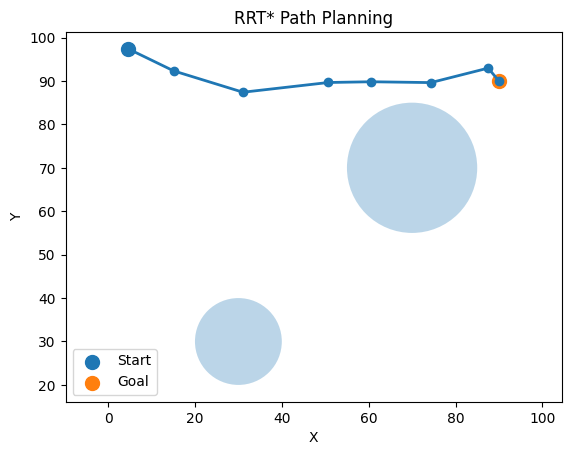

[14.17s] Victim-0 → UAV-1 (detect: 2.00s) → UGV-1 (travel: 12.17s)
DEBUG Victim-1: len(path) = 4
[20.29s] Victim-1 → UAV-1 (detect: 0.81s) → UGV-1 (travel: 5.31s)
DEBUG Victim-2: len(path) = 3
[26.07s] Victim-2 → UAV-1 (detect: 3.58s) → UGV-0 (travel: 2.20s)
DEBUG Victim-3: len(path) = 4
[31.49s] Victim-3 → UAV-1 (detect: 2.72s) → UGV-0 (travel: 2.69s)
DEBUG Victim-4: len(path) = 1
[34.94s] Victim-4 → UAV-1 (detect: 3.46s) → UGV-1 (travel: INF, path tidak ditemukan)
[34.94s] === FALCONIS FINISHED ===


In [ ]:
def run_falconis():
    env = simpy.Environment()
    np.random.seed(42)

    victims, uavs, ugvs = setup_falconis(env, num_victims=5, num_uav=2, num_ugv=2)

    ugvs[0].pos = np.array([0, 0, 0])
    victims[0].pos = np.array([90, 90, 0])

    env.process(falconis_process(env, victims, uavs, ugvs))
    env.run(until=200)


run_falconis()

In [ ]:
!pip install cma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 5.7 MB/s eta 0:00:00


In [ ]:
import cma
import numpy as np

# 0bjective dummy
def objective(x):
    return x[0]**2 + x[1]**2

N = 2
x0 = np.zeros(N)
sigma0 = 1.0

es = cma.CMAEvolutionStrategy(x0, sigma0, {
    'bounds': [-5, 5],
})

while not es.stop():
    X = es.ask()
    F = [objective(x) for x in X]
    es.tell(X, F)
    es.disp()

x_best = es.result.xbest
f_best = es.result.fbest
print("Best x:", x_best)
print("Best cost:", f_best)


(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=738654, Tue Apr  7 14:28:36 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      6 8.473915827876177e-02 1.0e+00 7.68e-01  7e-01  7e-01 0:00.0
    2     12 1.273402013529978e-02 1.2e+00 6.27e-01  5e-01  5e-01 0:00.0
    3     18 2.474297512391903e-03 1.1e+00 4.49e-01  3e-01  3e-01 0:00.0
   65    390 1.094728513019067e-16 1.6e+00 1.78e-05  3e-08  4e-08 0:00.1
Best x: [-7.19703295e-09 -7.59444323e-09]
Best cost: 1.0947285130190671e-16


In [ ]:
# === CMA-ES UNTUK URUTAN KORBAN ===

import numpy as np
import cma
import simpy

alpha = 0.001
DETECTION_TIME = 2.0
UGV_SPEED = 5.0
ENERGY_PER_METER = 1.0

env_opt = simpy.Environment()
np.random.seed(42)

victims, uavs_opt, ugvs_opt = setup_falconis(
    env_opt,
    num_victims=5,
    num_uav=2,
    num_ugv=1
)

ugv_start = ugvs_opt[0].pos[:2].copy()
def run_falconis_with_order(order: np.ndarray):
    total_time = 0.0
    total_energy = 0.0

    current_pos = ugv_start.copy()

    for idx in order:
        idx = int(idx)

        victim_pos = victims[idx].pos[:2]

        dist = np.linalg.norm(victim_pos - current_pos)

        travel_time = dist / UGV_SPEED
        detect_time = DETECTION_TIME

        travel_energy = dist * ENERGY_PER_METER

        total_time += travel_time + detect_time
        total_energy += travel_energy

        current_pos = victim_pos

    return total_time, total_energy


def objective(x: np.ndarray) -> float:
    x = np.asarray(x).ravel()

    # mapping
    order = np.argsort(x)

    total_time, total_energy = run_falconis_with_order(order)

    # fungsi objektif: minimasi kombinasi waktu + energi
    return total_time + alpha * total_energy

N = len(victims)
x0 = np.zeros(N)
sigma0 = 1.0

es = cma.CMAEvolutionStrategy(
    x0,
    sigma0,
    {
        'bounds': [-5, 5],
    }
)

while not es.stop():
    X = es.ask()
    F = [objective(x) for x in X]
    es.tell(X, F)
    es.disp()

x_best = es.result.xbest
f_best = es.result.fbest

print("Best x:", x_best)
print("Best order (urutan index korban):", np.argsort(x_best))
print("Best cost:", f_best)


(4_w,8)-aCMA-ES (mu_w=2.6,w_1=52%) in dimension 5 (seed=681998, Tue Apr  7 14:28:40 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      8 7.116950808708128e+01 1.0e+00 9.11e-01  8e-01  9e-01 0:00.0
    2     16 5.363399629116314e+01 1.2e+00 8.24e-01  7e-01  9e-01 0:00.0
    3     24 6.574956171410723e+01 1.4e+00 9.28e-01  8e-01  1e+00 0:00.0
   14    112 5.363399629116314e+01 3.2e+00 1.13e+00  8e-01  1e+00 0:00.1
Best x: [-0.05227992  0.01156858  1.30253123  0.54684632 -0.15247707]
Best order (urutan index korban): [4 0 1 3 2]
Best cost: 53.63399629116314


Best order dari CMA-ES: [4 0 1 3 2]

[0.00s] === FALCONIS (ORDER OPTIMAL) START ===
DEBUG Victim-4: len(path) = 3
[4.51s] Victim-4 → UAV-1 (detect: 3.46s) → UGV-1 (travel: 1.05s)
DEBUG Victim-0: len(path) = 4
[11.86s] Victim-0 → UAV-1 (detect: 2.07s) → UGV-1 (travel: 5.29s)
DEBUG Victim-1: len(path) = 5
[22.37s] Victim-1 → UAV-1 (detect: 0.81s) → UGV-1 (travel: 9.70s)
DEBUG Victim-3: len(path) = 6
[31.30s] Victim-3 → UAV-1 (detect: 2.72s) → UGV-0 (travel: 6.21s)
DEBUG Victim-2: len(path) = 4
[38.04s] Victim-2 → UAV-1 (detect: 3.58s) → UGV-0 (travel: 3.16s)
[38.04s] === FALCONIS (ORDER OPTIMAL) FINISHED ===


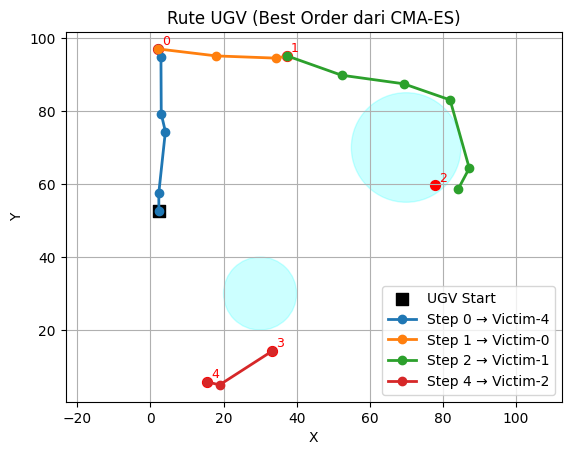

In [ ]:
# === FALCONIS FINAL ===
import numpy as np
import simpy
import matplotlib.pyplot as plt

def falconis_process_with_order(env, victims, uavs, ugvs, order):
    print(f"\n[{env.now:.2f}s] === FALCONIS (ORDER OPTIMAL) START ===")

    for step, idx in enumerate(order):
        idx = int(idx)
        victim = victims[idx]

        best_uav = min(uavs, key=lambda u: np.linalg.norm(u.pos - victim.pos))
        best_ugv = min(ugvs, key=lambda g: np.linalg.norm(g.pos - victim.pos))

        # DETEKSI OLEH UAV
        detect_time = best_uav.detect_victim(victim)
        yield env.timeout(detect_time)

        # RENCANA JALUR UGV → VICTIM (RRT*)
        path = rrt_star(best_ugv.pos, victim.pos, best_ugv.obstacles)
        print(f"DEBUG {victim.name}: len(path) = {len(path)}")

        # UGV
        travel_time = best_ugv.move_to_victim(victim, path)

        if np.isinf(travel_time):
            print(
                f"[{env.now:.2f}s] {victim.name} → {best_uav.name} "
                f"(detect: {detect_time:.2f}s) "
                f"→ {best_ugv.name} (travel: INF, path tidak ditemukan)"
            )
        else:
            yield env.timeout(travel_time)
            print(
                f"[{env.now:.2f}s] {victim.name} → {best_uav.name} "
                f"(detect: {detect_time:.2f}s) "
                f"→ {best_ugv.name} (travel: {travel_time:.2f}s)"
            )

    print(f"[{env.now:.2f}s] === FALCONIS (ORDER OPTIMAL) FINISHED ===")


def plot_best_order_map(ugv_start, victims, order, obstacles):
    plt.figure()

    for center, radius in obstacles:
        circle = plt.Circle((center[0], center[1]), radius, alpha=0.2, color='cyan')
        plt.gca().add_patch(circle)

    plt.scatter(ugv_start[0], ugv_start[1], marker='s', c='black', s=80, label='UGV Start')

    current_pos = np.array([ugv_start[0], ugv_start[1], 0.0])

    for step, idx in enumerate(order):
        idx = int(idx)
        victim = victims[idx]

        path = rrt_star(current_pos, victim.pos, obstacles)
        path = np.array(path)

        if len(path) > 1:
            plt.plot(
                path[:, 0],
                path[:, 1],
                marker='o',
                linewidth=2,
                label=f"Step {step} → {victim.name}"
            )

        vx, vy = victim.pos[0], victim.pos[1]
        plt.scatter(vx, vy, c='red', s=50)
        plt.text(vx + 1, vy + 1, f"{step}", color='red', fontsize=9)

        current_pos = victim.pos

    plt.title("Rute UGV (Best Order dari CMA-ES)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis('equal')
    plt.legend()
    plt.grid(True)
    plt.show()


def run_falconis_with_best_order(best_order):
    env = simpy.Environment()

    np.random.seed(42)

    num_victims = len(best_order)

    #  === SETUP ENVIRONMENT====
    victims, uavs, ugvs = setup_falconis(
        env,
        num_victims=num_victims,
        num_uav=2,
        num_ugv=2
    )

    ugv_start_2d = ugvs[0].pos[:2].copy()
    obstacles = ugvs[0].obstacles

    env.process(falconis_process_with_order(env, victims, uavs, ugvs, best_order))
    env.run(until=200)

    plot_best_order_map(ugv_start_2d, victims, best_order, obstacles)

best_order = np.argsort(x_best)
print("Best order dari CMA-ES:", best_order)
run_falconis_with_best_order(best_order)


In [ ]:
# ==== PERBANDINGAN URUTAN NAIVE VS CMA-ES (FALCONIS) ====

import numpy as np

def compute_metrics_for_order(order):
    total_time = 0.0
    total_energy = 0.0
    total_path = 0.0

    current_pos = ugv_start.copy()

    for idx in order:
        idx = int(idx)
        victim_pos = victims[idx].pos[:2]

        dist = np.linalg.norm(victim_pos - current_pos)
        travel_time = dist / UGV_SPEED
        detect_time = DETECTION_TIME
        travel_energy = dist * ENERGY_PER_METER

        total_time += travel_time + detect_time
        total_energy += travel_energy
        total_path += dist

        current_pos = victim_pos

    return total_time, total_path, total_energy


naive_order = np.arange(len(victims))
best_order = np.argsort(x_best)

t_naive, L_naive, E_naive = compute_metrics_for_order(naive_order)
t_opt,   L_opt,   E_opt   = compute_metrics_for_order(best_order)

def percent_reduction(old, new):
    return (old - new) / old * 100 if old > 0 else 0.0

p_time  = percent_reduction(t_naive, t_opt)
p_path  = percent_reduction(L_naive, L_opt)
p_energy = percent_reduction(E_naive, E_opt)

print("=== Perbandingan FALCONIS: Naive vs CMA-ES ===")
print("Naive order :", naive_order)
print("Best order  :", best_order)
print()
print(f"Total mission time naive  = {t_naive:.2f} s")
print(f"Total mission time optimal= {t_opt:.2f} s")
print(f"Pengurangan mission time  = {p_time:.2f} %")
print()
print(f"Total path length naive   = {L_naive:.2f} m")
print(f"Total path length optimal = {L_opt:.2f} m")
print(f"Pengurangan path length   = {p_path:.2f} %")
print()
print(f"Total energy naive        = {E_naive:.2f} J")
print(f"Total energy optimal      = {E_opt:.2f} J")
print(f"Penghematan energi        = {p_energy:.2f} %")


=== Perbandingan FALCONIS: Naive vs CMA-ES ===
Naive order : [0 1 2 3 4]
Best order  : [4 0 1 3 2]

Total mission time naive  = 69.91 s
Total mission time optimal= 53.42 s
Pengurangan mission time  = 23.59 %

Total path length naive   = 299.56 m
Total path length optimal = 217.08 m
Pengurangan path length   = 27.53 %

Total energy naive        = 299.56 J
Total energy optimal      = 217.08 J
Penghematan energi        = 27.53 %


In [ ]:
# ==== ANALISIS SENSITIVITAS (FALCONIS vs UGV_SPEED) ====

import numpy as np

def compute_metrics_for_order_with_speed(order, ugv_speed):
    total_time = 0.0
    total_energy = 0.0
    total_path = 0.0

    current_pos = ugv_start.copy()

    for idx in order:
        idx = int(idx)
        victim_pos = victims[idx].pos[:2]

        dist = np.linalg.norm(victim_pos - current_pos)
        travel_time = dist / ugv_speed
        detect_time = DETECTION_TIME
        travel_energy = dist * ENERGY_PER_METER

        total_time += travel_time + detect_time
        total_energy += travel_energy
        total_path += dist

        current_pos = victim_pos

    return total_time, total_path, total_energy


naive_order = np.arange(len(victims))
best_order = np.argsort(x_best)

test_speeds = [3.0, 5.0, 8.0, 10.0]

print("=== Analisis Sensitivitas vs UGV_SPEED ===")
for spd in test_speeds:
    t_n, L_n, E_n = compute_metrics_for_order_with_speed(naive_order, spd)
    t_o, L_o, E_o = compute_metrics_for_order_with_speed(best_order, spd)

    p_t = (t_n - t_o) / t_n * 100 if t_n > 0 else 0.0
    p_e = (E_n - E_o) / E_n * 100 if E_n > 0 else 0.0

    print(f"\nUGV_SPEED = {spd:.1f} m/s")
    print(f"  Naive : time = {t_n:.2f} s, energy = {E_n:.2f} J")
    print(f"  Opt   : time = {t_o:.2f} s, energy = {E_o:.2f} J")
    print(f"  Pengurangan time  ≈ {p_t:.2f} %")
    print(f"  Penghematan energi≈ {p_e:.2f} %")


=== Analisis Sensitivitas vs UGV_SPEED ===

UGV_SPEED = 3.0 m/s
  Naive : time = 109.85 s, energy = 299.56 J
  Opt   : time = 82.36 s, energy = 217.08 J
  Pengurangan time  ≈ 25.03 %
  Penghematan energi≈ 27.53 %

UGV_SPEED = 5.0 m/s
  Naive : time = 69.91 s, energy = 299.56 J
  Opt   : time = 53.42 s, energy = 217.08 J
  Pengurangan time  ≈ 23.59 %
  Penghematan energi≈ 27.53 %

UGV_SPEED = 8.0 m/s
  Naive : time = 47.44 s, energy = 299.56 J
  Opt   : time = 37.14 s, energy = 217.08 J
  Pengurangan time  ≈ 21.73 %
  Penghematan energi≈ 27.53 %

UGV_SPEED = 10.0 m/s
  Naive : time = 39.96 s, energy = 299.56 J
  Opt   : time = 31.71 s, energy = 217.08 J
  Pengurangan time  ≈ 20.64 %
  Penghematan energi≈ 27.53 %
